# Lakeside heating DSM — PyTorch ResMLP (train alt)

> **DO NOT RELEASE FOR OPERATIONAL DSM.** Honesty stamp: **`HYBRID_SCREENING`**.

**This notebook is the only supported ResMLP train path.** CLI refuses unless `VIBE22_ALLOW_CLI_TRAIN=1`.

Trains **ResMLP multi-head** on the **real BAS 15-min store only**. Does **not** overwrite the hybrid desktop walk.

| | |
|---|---|
| Data | `REAL_BAS_15MIN` site store |
| Artifact | `real_baseline_15min_torch_v1.*` |
| Honesty | `HYBRID_SCREENING` |
| Splits | Same `chrono_splits` contract as sklearn when available; else GroupKFold fallback |
| Recursive | Real `evaluate_recursive_days` — if insufficient days, card status is `not_evaluated` (promote rejects) |

Lean default: winter, 24 days, 25 epochs. Set `FULL=True` for heavier CV.


## 0 · Setup


In [1]:
from pathlib import Path
import sys, json, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display, Markdown

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "ml"))

from artifact_paths import artifact_paths
from notebook_proof import prove_real_store_load
from notebook_plots import save_fig
from chrono_splits import build_split_manifest, write_manifest
from train_real_baseline_15min import load_real_baseline_frame
from train_real_baseline_torch_15min import (
    train_torch_baseline,
    export_torch_baseline_artifacts,
)

PATHS = artifact_paths()
PATHS["figures"].mkdir(parents=True, exist_ok=True)
OUT = PATHS["figures"].parent
SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", r"C:\Users\ben\OneDrive\Desktop\testing\sp_creekside"))

FULL = False
WINTER_ONLY = True
MAX_DAYS = 24 if not FULL else None
N_SPLITS = 3
EPOCHS = 25 if not FULL else 40

print("ROOT", ROOT)
print("SITE", SITE)
print("device", "cpu" if not __import__("torch").cuda.is_available() else "cuda", "EPOCHS", EPOCHS, "MAX_DAYS", MAX_DAYS)
print("honesty HYBRID_SCREENING — DO NOT RELEASE FOR OPERATIONAL DSM")


ROOT C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22
SITE C:\Users\ben\OneDrive\Desktop\testing\sp_creekside
device cpu EPOCHS 25 MAX_DAYS 24
honesty HYBRID_SCREENING — DO NOT RELEASE FOR OPERATIONAL DSM


## 1 · Proof — real store only


In [2]:
real_df, meta = prove_real_store_load(site=SITE)
assert (real_df["provenance"] == "REAL_BAS_15MIN").all()
winter = real_df[real_df["month"].isin([11, 12, 1, 2, 3])]
print("winter rows", len(winter), "days", winter["day"].nunique())


### Proof — real BAS 15-min store (component A)
- **Parquet:** `C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\ml\artifacts\real_baseline_15min_v1.parquet`
- **Rows / days:** 32156 / 335
- **Provenance:** `REAL_BAS_15MIN` (no EnergyPlus rows)
- **Zone temp columns:** ['zone_temp_1F_A_f', 'zone_temp_1F_B_f', 'zone_temp_1F_C_f', 'zone_temp_1F_D_f', 'zone_temp_2F_A_f', 'zone_temp_2F_B_f']
- **Honesty:** measured BAS only — hybrid baseline component
- **Build row_count:** 32156

,day,step_15,facility_kw,oat_f,zone_temp_1F_A_f,zone_temp_1F_B_f,provenance
0,2025-08-02,0,26.0,56.800000,69.655556,72.295833,REAL_BAS_15MIN
1,2025-08-02,1,24.0,56.566667,69.663889,72.391667,REAL_BAS_15MIN
2,2025-08-02,2,26.0,56.366667,69.586111,72.445833,REAL_BAS_15MIN
3,2025-08-02,3,24.0,56.166667,69.638889,72.454167,REAL_BAS_15MIN
4,2025-08-02,4,28.0,55.966667,69.566667,72.462500,REAL_BAS_15MIN
5,2025-08-02,5,26.0,55.650000,69.625000,72.450000,REAL_BAS_15MIN
6,2025-08-02,6,24.0,55.275000,69.522222,72.425000,REAL_BAS_15MIN
7,2025-08-02,7,26.0,54.900000,69.550000,72.433333,REAL_BAS_15MIN


winter rows 14492 days 151


## 2 · Train ResMLP (writes card + ONNX + .pt)


In [3]:
prove_real_store_load()
train_df = load_real_baseline_frame(winter_only=WINTER_ONLY, max_days=MAX_DAYS)
print("rows", len(train_df), "days", train_df["day"].nunique())

split_manifest = build_split_manifest(train_df)
write_manifest(OUT / "eval" / "split_manifest_torch.json", split_manifest)
print("chrono folds", len(split_manifest.get("folds", [])), "final_test", len(split_manifest.get("final_winter_test", [])))

result = train_torch_baseline(
    train_df,
    n_splits=N_SPLITS,
    epochs=EPOCHS,
    split_manifest=split_manifest,
)
paths = export_torch_baseline_artifacts(result, OUT)
card = json.loads(paths["card"].read_text(encoding="utf-8"))
assert card.get("honesty") == "HYBRID_SCREENING"
held = card.get("cv_recursive_96_heldout") or {}
print("cv_recursive_96_heldout", json.dumps(held, indent=2)[:1500])
if held.get("status") == "not_evaluated":
    display(Markdown("**Recursive held-out: `not_evaluated`** — promote will reject this torch card (expected when coverage is thin)."))
else:
    assert "provisional" not in json.dumps(held).lower()
display(Markdown("### Torch baseline card written"))
print(paths)


### Proof — real BAS 15-min store (component A)
- **Parquet:** `C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\ml\artifacts\real_baseline_15min_v1.parquet`
- **Rows / days:** 32156 / 335
- **Provenance:** `REAL_BAS_15MIN` (no EnergyPlus rows)
- **Zone temp columns:** ['zone_temp_1F_A_f', 'zone_temp_1F_B_f', 'zone_temp_1F_C_f', 'zone_temp_1F_D_f', 'zone_temp_2F_A_f', 'zone_temp_2F_B_f']
- **Honesty:** measured BAS only — hybrid baseline component
- **Build row_count:** 32156

,day,step_15,facility_kw,oat_f,zone_temp_1F_A_f,zone_temp_1F_B_f,provenance
0,2025-08-02,0,26.0,56.800000,69.655556,72.295833,REAL_BAS_15MIN
1,2025-08-02,1,24.0,56.566667,69.663889,72.391667,REAL_BAS_15MIN
2,2025-08-02,2,26.0,56.366667,69.586111,72.445833,REAL_BAS_15MIN
3,2025-08-02,3,24.0,56.166667,69.638889,72.454167,REAL_BAS_15MIN
4,2025-08-02,4,28.0,55.966667,69.566667,72.462500,REAL_BAS_15MIN
5,2025-08-02,5,26.0,55.650000,69.625000,72.450000,REAL_BAS_15MIN
6,2025-08-02,6,24.0,55.275000,69.522222,72.425000,REAL_BAS_15MIN
7,2025-08-02,7,26.0,54.900000,69.550000,72.433333,REAL_BAS_15MIN


rows 2304 days 24
chrono folds 3 final_test 20
fold 1/3
  TF peak MAE=3.902
fold 2/3
  TF peak MAE=85.185
fold 3/3
  TF peak MAE=17.881


W0806 14:59:32.384000 3664 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0806 14:59:34.016000 3664 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0806 14:59:34.020000 3664 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align
W0806 14:59:34.022000 3664 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool
W0806 14:59:34.0240

[torch.onnx] Obtain model graph for `ResMLPMulti([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResMLPMulti([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
cv_recursive_96_heldout {
  "status": "not_evaluated",
  "reason": "no held-out day had >=80 rows for a recursive 96-step rollout"
}


**Recursive held-out: `not_evaluated`** — promote will reject this torch card (expected when coverage is thin).

### Torch baseline card written

{'pt': WindowsPath('C:/Users/ben/Documents/py-bacnet-stacks-playground/vibe_code_apps_22/ml/artifacts/real_baseline_15min_torch_v1.pt'), 'onnx': WindowsPath('C:/Users/ben/Documents/py-bacnet-stacks-playground/vibe_code_apps_22/ml/artifacts/real_baseline_15min_torch_v1.onnx'), 'meta': WindowsPath('C:/Users/ben/Documents/py-bacnet-stacks-playground/vibe_code_apps_22/ml/artifacts/real_baseline_15min_torch_v1_feature_meta.json'), 'card': WindowsPath('C:/Users/ben/Documents/py-bacnet-stacks-playground/vibe_code_apps_22/ml/artifacts/real_baseline_15min_torch_v1_model_card.json')}


## 3 · Compare to sklearn ship baseline (read-only)


,family,mae_peak_05_09
0,sklearn_extra_trees,16.250
1,resmlp_multihead,35.656


ResMLP peak MAE **35.7 kW** vs sklearn **16.2 kW**. Desktop hybrid walk stays on sklearn (sklearn notebook promote).

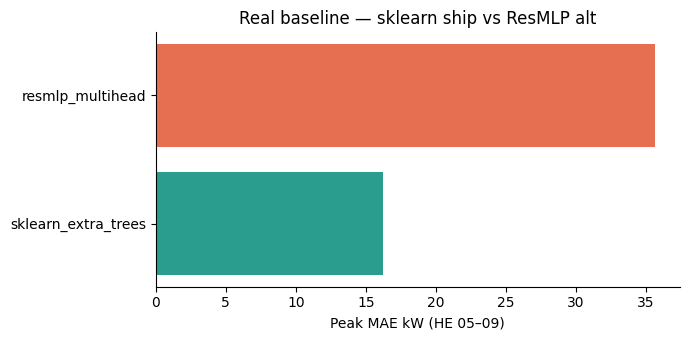

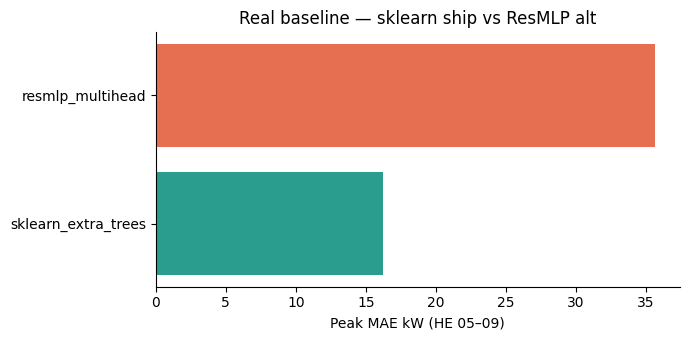

In [4]:
sk_path = PATHS["real_baseline_card"]
assert sk_path.is_file(), f"missing {sk_path} — Run All sklearn notebook first"
sk_card = json.loads(sk_path.read_text(encoding="utf-8"))
sk_peak = sk_card["cv_teacher_forced"][sk_card["champion"]].get(
    "facility_kw_mae_peak_05_09",
    sk_card["cv_teacher_forced"][sk_card["champion"]].get("facility_kw", {}).get("mae_peak_05_09"),
)
torch_peak = card["cv_teacher_forced"]["facility_kw_mae_peak_05_09"]

cmp = pd.DataFrame([
    {"family": f"sklearn_{sk_card['champion']}", "mae_peak_05_09": sk_peak},
    {"family": "resmlp_multihead", "mae_peak_05_09": torch_peak},
]).sort_values("mae_peak_05_09")
display(cmp.round(3))
display(Markdown(
    f"ResMLP peak MAE **{torch_peak:.1f} kW** vs sklearn **{sk_peak:.1f} kW**. "
    f"Desktop hybrid walk stays on sklearn (sklearn notebook promote)."
))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(cmp["family"], cmp["mae_peak_05_09"], color=["#2a9d8f", "#e76f51"])
ax.set_xlabel("Peak MAE kW (HE 05–09)")
ax.set_title("Real baseline — sklearn ship vs ResMLP alt")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
save_fig(PATHS["figures"] / "hybrid_torch_vs_sklearn.png", fig)
display(fig)
plt.close(fig)


## Honesty

- Trained on measured BAS only (`REAL_BAS_15MIN`).
- Does not overwrite hybrid desktop walk.
- Model training only via this notebook (CLI gated).


## Honesty — DO NOT RELEASE FOR OPERATIONAL DSM

- Torch artifacts are an alternate baseline screen; hybrid ship remains sklearn+ONNX.
- Same chrono split contract when `split_manifest` is passed; recursive uses `evaluate_recursive_days`.
- If recursive coverage is insufficient, card status is **`not_evaluated`** (never a provisional teacher-forced copy).
